In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from scipy.stats import norm
from scipy.stats import gaussian_kde

In [43]:
# distribution parameters

division_mu = 4.80
division_sigma = 0.42
division_loc = -0.32

radius = 0.67

growth_mu = 1.15
growth_sigma = 0.31

**Corresponding names:**

radius (feature name in data) -> radius (parameter name in simulation module)

Elongation_Rate (feature name in data) -> elongation rate (parameter name in simulation module)

targetVol (feature name in data) -> division threshold (parameter name in simulation module)

startVol (feature name in data) -> start volumn (parameter name in simulation module)

In [44]:
def get_plot(data, samples):
    
    data = np.array(data)
    
    mean_exp = data.mean()
    mean_sim = samples.mean()

    x_exp = np.linspace(data.min(), data.max(), 1000)
    x_sim = np.linspace(min(samples), max(samples), 1000)
    
    kde = gaussian_kde(data)
    pdf = lognorm.pdf(x_sim, s=division_sigma, loc=division_loc, scale=division_mu)

    plt.hist(data, bins=100, density=True, alpha=0.5)
    plt.hist(samples, bins=100, density=True, alpha=0.5)
    
    plt.plot(x_exp, kde(x_exp))
    plt.plot(x_sim, pdf)
    
    plt.axvline(mean_exp, color='yellow', linestyle='--', linewidth=1, label=f"exp_mean = {mean_exp:.2f}")
    plt.axvline(mean_sim, color='blue', linestyle='--', linewidth=1, label=f"sim_mean = {mean_sim:.2f}")

    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title("Histogram + KDE with Mean")
    plt.legend()
    plt.show()

In [45]:
def get_plot_exp(data):
    data = np.array(data)
    mean_val = data.mean()

    kde = gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 1000)

    plt.hist(data, bins=100, density=True)
    plt.plot(x, kde(x))
    plt.axvline(mean_val, color='yellow', linestyle='--', linewidth=2, label=f"Mean = {mean_val:.2f}")

    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title("Histogram + KDE with Mean")
    plt.legend()
    plt.show()

In [46]:
# get feature values
exp_path = "D:/Projects/GNN Research/Data Files/_exp_data/node"
exp_files = [f for f in os.listdir(exp_path)]
list_1 = []
list_2 = []
list_3 = []
list_4 = []

feature_names = ["radius","Elongation_Rate","targetVol","startVol"]  ### depending on which features we are checking
for f in exp_files:
    f_path = exp_path + "/" + f
    exp_df = pd.read_csv(f_path)
    list_1 += exp_df[feature_names[0]].dropna().tolist()
    list_2 += exp_df[feature_names[1]].dropna().tolist()
    list_3 += exp_df[feature_names[2]].dropna().tolist()
    list_4 += exp_df[feature_names[3]].dropna().tolist()

print("total points: ", exp_df.shape[0]*len(exp_files))
print("non-empty points in 4 lists: ", len(list_1), len(list_2), len(list_3), len(list_4))

total points:  53016
non-empty points in 4 lists:  69056 68510 69056 69056


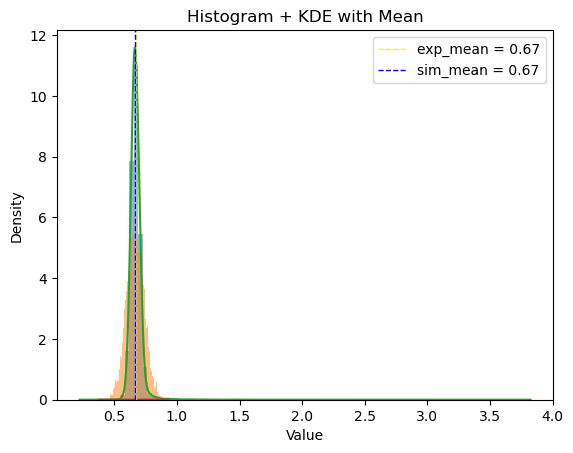

In [48]:
# cell radius
samples = norm.rvs(loc=radius, scale=0.07, size=10000)
get_plot(list_1, samples)

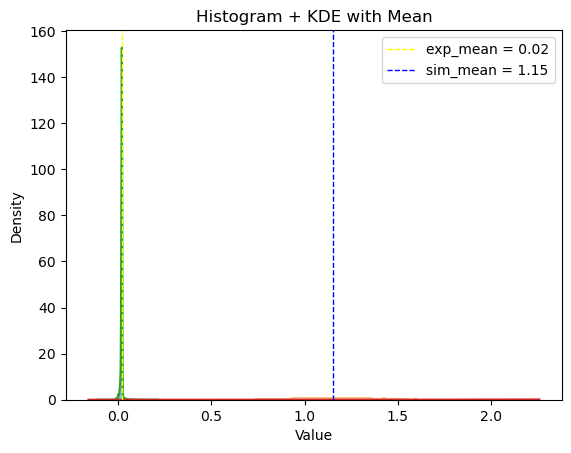

In [53]:
# maximum growth rate
samples = norm.rvs(loc=growth_mu, scale=growth_sigma, size=10000)
get_plot(list_2, samples)

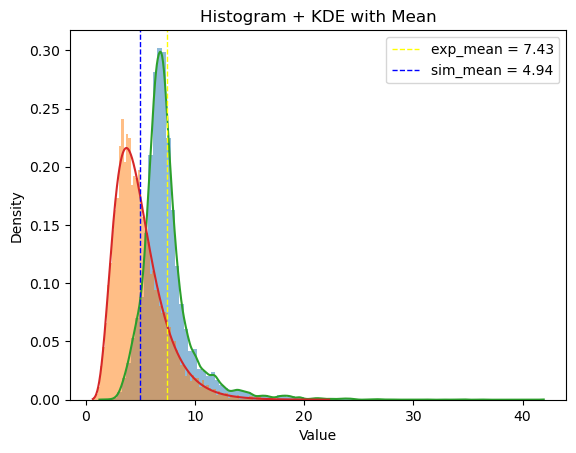

In [50]:
# division length threshold
samples = lognorm.rvs(division_sigma, loc=division_loc, scale=division_mu, size=10000)
get_plot(list_3, samples)

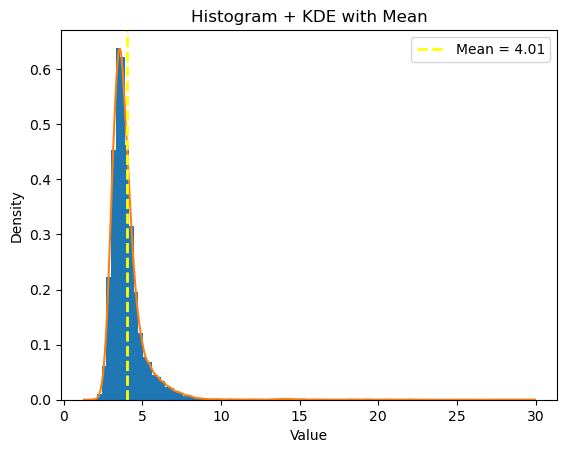

In [52]:
# Ati said it's important
get_plot_exp(list_4)